# Customer Segmentation & Churn Prediction

## Step 3: Customer Analysis and Machine Learning

### Objectives

- Perform RFM Analysis
- Segment customers
- Define churn
- Prepare features
- Train ML model
- Evaluate performance
- Generate business insights

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [10]:
df_clean = pd.read_csv("../data/online_retail_clean.csv")

In [16]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [17]:
df_clean.shape

(392692, 9)

In [13]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [18]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 27.0 MB


In [19]:
df_clean.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,561874.000000,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,572061.000000,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,13087.063759,180.492832,NaN,22.241836,1713.539549,311.099224


In [20]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

In [21]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

In [22]:
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

### Observation

The RFM table contains one record for each customer.

The three metrics summarize customer purchasing behaviour:

- **Recency** measures how recently a customer made a purchase.
- **Frequency** measures how often a customer purchases.
- **Monetary** measures the total amount spent by the customer.

These features will be used to segment customers and identify customers who are likely to churn.

In [23]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [24]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


### Observation

- The RFM table contains **one record for each of the 4,338 customers**.
- Each customer is represented by three metrics: **Recency, Frequency, and Monetary**.
- These metrics summarize customer purchasing behavior and will be used for customer segmentation and churn analysis.

## Distribution of RFM Metrics

Before segmenting customers, it is important to understand how the three RFM metrics are distributed.

Histograms help identify skewness, outliers, and customer purchasing patterns.

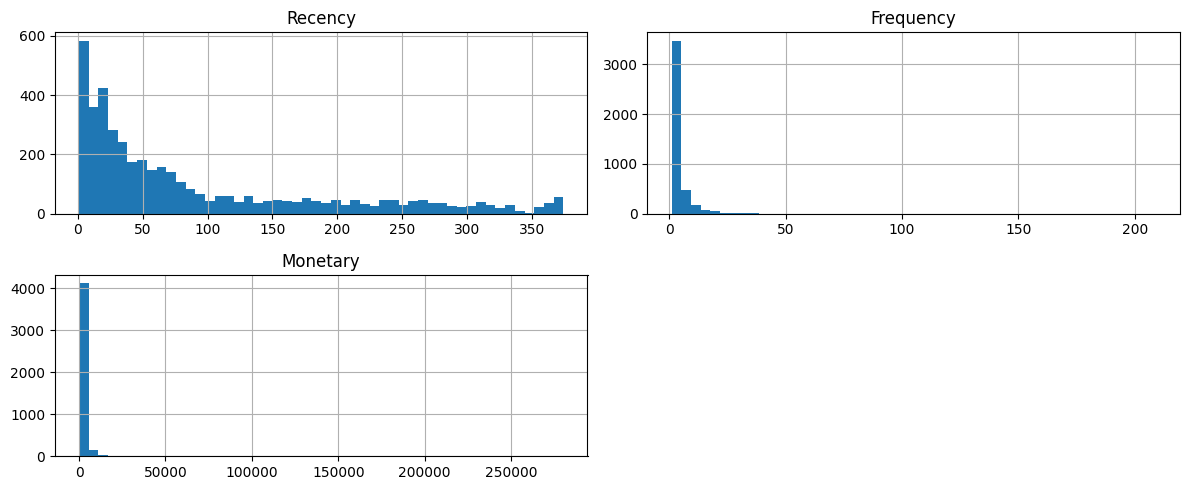

In [25]:
rfm[['Recency', 'Frequency', 'Monetary']].hist(
    bins=50,
    figsize=(12,5)
)

plt.tight_layout()
plt.show()

### Observation

- **Frequency** and **Monetary** distributions are highly right-skewed.
- Most customers purchase only a few times and spend relatively small amounts.
- A small number of customers make frequent purchases and contribute a large share of the revenue.
- **Recency** is also right-skewed, suggesting many customers purchased recently, while a smaller group has not made a purchase for a long time.

## Log Transformation

The Frequency and Monetary distributions contain extreme values.

A logarithmic transformation reduces skewness, making the data easier to analyze and compare.

In [26]:
import numpy as np

rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm['Monetary'])

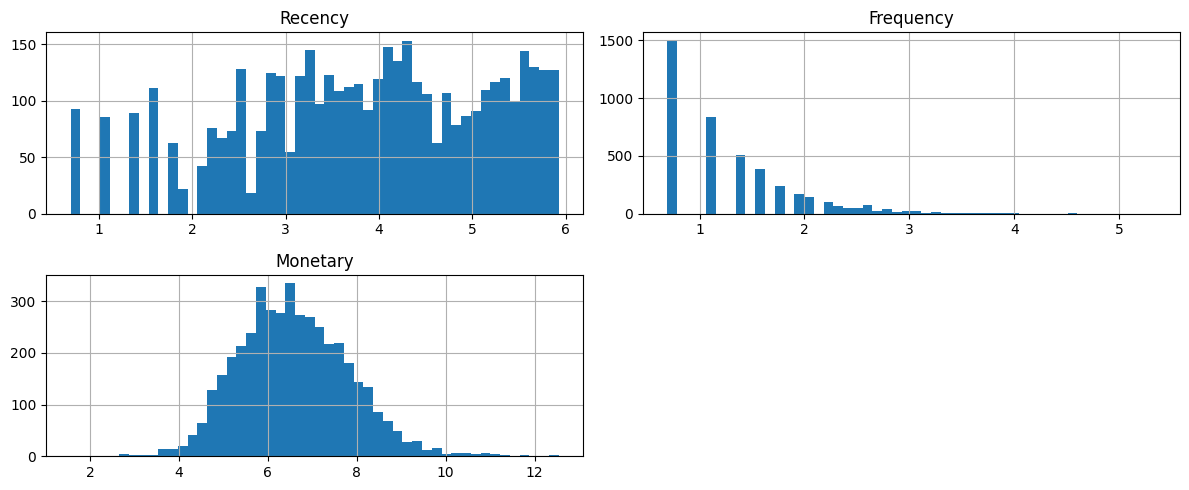

In [27]:
rfm_log[['Recency','Frequency','Monetary']].hist(
    bins=50,
    figsize=(12,5)
)

plt.tight_layout()
plt.show()

### Observation

- Log transformation reduces the impact of extreme values.
- The RFM distributions become less skewed, especially **Monetary**.
- The transformed features are more suitable for customer segmentation and predictive modeling.

## Customer Scoring

Each customer is assigned a score from 1 to 5 for:

- Recency
- Frequency
- Monetary

Higher scores represent better customer behaviour.

In [28]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [29]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346.0,326,1,77183.60,1,1,5
1,12347.0,2,7,4310.00,5,5,5
2,12348.0,75,4,1797.24,2,4,4
3,12349.0,19,1,1757.55,4,1,4
4,12350.0,310,1,334.40,1,1,2


### Observation

- Each customer has an **R, F, and M score** ranging from **1 to 5**.
- Higher scores indicate more valuable customers.
- These scores will be used to create customer segments.

## Creating the Overall RFM Score

The individual Recency, Frequency, and Monetary scores are combined into a single RFM score.

This score provides a quick summary of each customer's purchasing behaviour and forms the basis for customer segmentation.

In [30]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [31]:
rfm[['CustomerID','R_score','F_score','M_score','RFM_Score']].head()

,CustomerID,R_score,F_score,M_score,RFM_Score
0,12346.0,1,1,5,115
1,12347.0,5,5,5,555
2,12348.0,2,4,4,244
3,12349.0,4,1,4,414
4,12350.0,1,1,2,112


## Customer Segmentation

Customers are grouped into meaningful business segments based on their Recency and Frequency scores.

Each segment represents a different level of customer engagement and loyalty.

In [32]:
def segment_customer(df):

    if df['R_score'] >= 4 and df['F_score'] >= 4:
        return "VIP"

    elif df['R_score'] >= 3 and df['F_score'] >= 3:
        return "Loyal Customer"

    elif df['R_score'] >= 3 and df['F_score'] <= 2:
        return "Potential Loyalist"

    elif df['R_score'] <= 2 and df['F_score'] >= 3:
        return "At Risk"

    elif df['R_score'] == 1 and df['F_score'] >= 4:
        return "Can't Lose Them"

    else:
        return "Need Attention"

In [33]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [34]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,5,115,Need Attention
1,12347.0,2,7,4310.00,5,5,5,555,VIP
2,12348.0,75,4,1797.24,2,4,4,244,At Risk
3,12349.0,19,1,1757.55,4,1,4,414,Potential Loyalist
4,12350.0,310,1,334.40,1,1,2,112,Need Attention


### Observation

- Each customer has been assigned to an RFM-based customer segment.
- Customers in the same segment share similar purchasing behavior.
- These segments can be used to improve customer retention and marketing strategies.

## Segment Distribution

In [35]:
rfm['Segment'].value_counts()

Segment
VIP                   1121
Need Attention        1074
Loyal Customer         821
At Risk                661
Potential Loyalist     661
Name: count, dtype: int64

### Observation

- Customers are distributed across **five RFM segments**, reflecting different levels of engagement and loyalty.
- **VIP (1,121)** and **Need Attention (1,074)** are the largest customer groups.
- This segmentation enables the business to design targeted retention and marketing strategies for different customer groups.

## Visualizing Customer Segments

A bar chart is used to compare the number of customers in each segment.

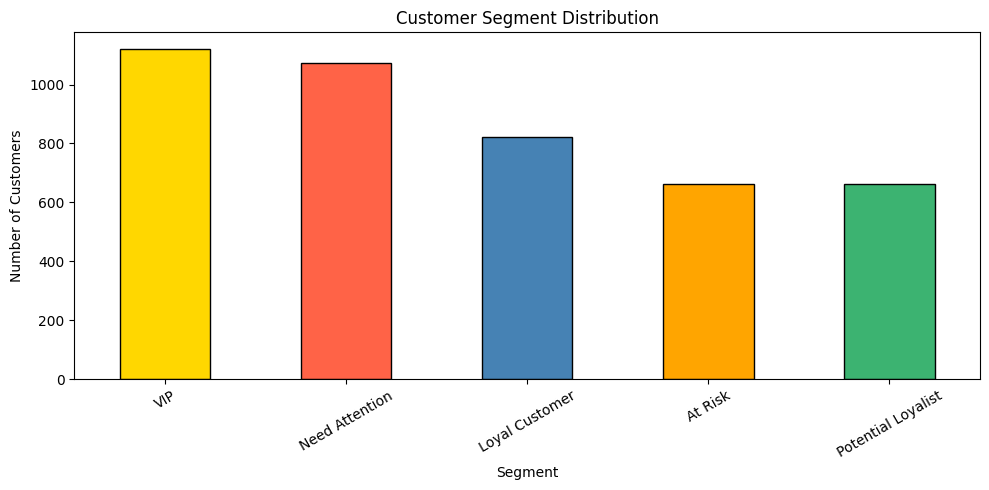

In [36]:
import matplotlib.pyplot as plt

colors = ['gold','tomato','steelblue',
          'orange','mediumseagreen','purple']

rfm['Segment'].value_counts().plot(
    kind='bar',
    figsize=(10,5),
    color=colors[:len(rfm['Segment'].unique())],
    edgecolor='black'
)

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Business Insight

- VIP customers represent the most valuable customer group.
- Customers in the "Need Attention" and "At Risk" segments should be targeted with retention campaigns.
- Potential Loyalists can be converted into loyal customers through personalized offers and engagement.

## Creating a Churn Indicator

A simple churn indicator is created using Recency.

Customers who have not made a purchase for more than 180 days are considered churned.

In [37]:
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 180 else 0)

In [38]:
rfm['Churn'].value_counts()

Churn
0    3478
1     860
Name: count, dtype: int64

### Observation

- The churn feature classifies customers into **Active (0)** and **Churned (1)**.
- The dataset contains **3,478 active customers** and **860 churned customers**.
- This target variable will be used to train and evaluate the customer churn prediction model.

## Customer Segment Visualization

A scatter plot is used to visualize how customer segments differ based on their purchasing frequency and total spending.

This helps identify high-value customers and customers who require retention efforts.

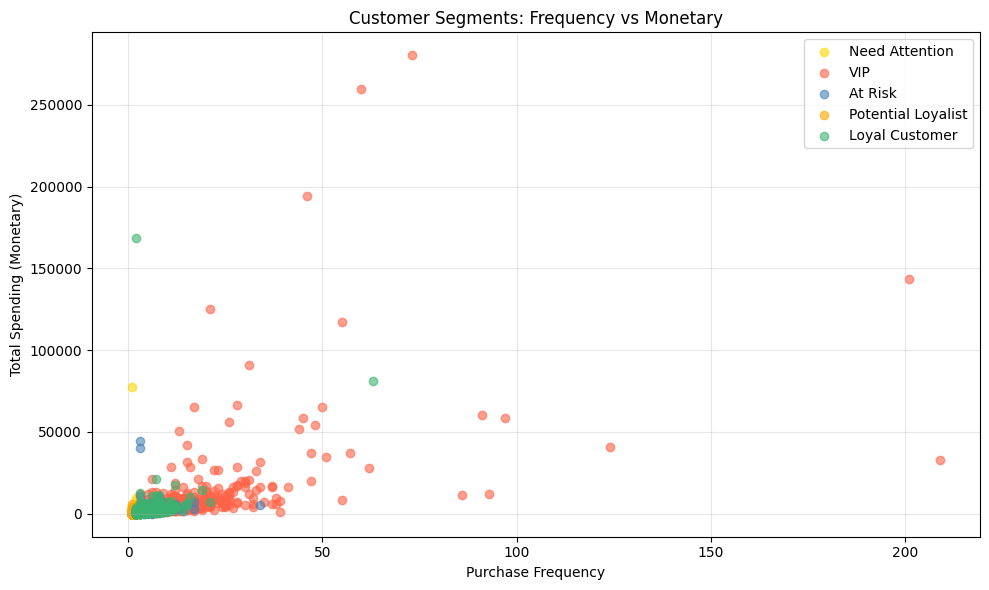

In [39]:
plt.figure(figsize=(10,6))

segments = rfm['Segment'].unique()

colors = [
    'gold',
    'tomato',
    'steelblue',
    'orange',
    'mediumseagreen',
    'purple'
]

for segment, color in zip(segments, colors):

    subset = rfm[rfm['Segment'] == segment]

    plt.scatter(
        subset['Frequency'],
        subset['Monetary'],
        label=segment,
        color=color,
        alpha=0.6
    )

plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending (Monetary)")
plt.title("Customer Segments: Frequency vs Monetary")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../images/frequency_vs_monetary.png", dpi=100, bbox_inches="tight")
plt.show()

### Business Insights

- **VIP customers** are the most valuable customer segment, contributing the highest spending and purchase frequency.
- **Loyal Customers** represent a stable customer base with consistent purchasing behavior.
- **At Risk** and **Need Attention** customers show lower engagement, making them ideal targets for retention and re-engagement campaigns.
- Customer segmentation enables the business to allocate marketing resources more effectively by tailoring strategies to each customer group.

# Final Business Insights

From this analysis, I observed that customer purchasing behavior varies significantly across different customer groups. While most customers purchase only a few times, a small group contributes a large share of the overall revenue.

## Key Findings

- Most customers purchase infrequently and spend relatively small amounts.
- A small percentage of customers generates a significant portion of the total revenue.
- The RFM framework successfully grouped customers based on their purchasing behavior.
- **VIP** and **Loyal Customers** represent the highest-value customer segments.
- **Need Attention** and **At Risk** customers show lower engagement and may require retention efforts.
- Customer recency provides a simple way to identify customers who are more likely to churn.

## Business Recommendations

- Reward **VIP** customers with loyalty programs and exclusive offers to encourage repeat purchases.
- Nurture **Potential Loyalists** through personalized recommendations and targeted promotions.
- Re-engage **Need Attention** and **At Risk** customers using reminder campaigns, discounts, or special offers.
- Continuously monitor customer behavior to identify inactive customers early.
- Build a machine learning model in the future to predict customer churn more accurately using the RFM features.

In [43]:
rfm.to_csv("../data/customer_rfm_analysis.csv", index=False)

In [44]:
import os

os.listdir("../data")

['online_retail_clean.csv',
 'Online Retail.xlsx',
 'customer_rfm_analysis.csv',
 '.ipynb_checkpoints']